# Projeto Final EBAC - Fraude Bancária

#### By: Leonardo Prado

Objetivo: Desenvolver e otimizar um modelo de detecção de fraudes, aplicando técnicas robustas para mitigar o desbalanceamento do dataset (pós-PCA), com o propósito de maximizar o F1-Score e, em termos de impacto financeiro, priorizar a minimização de Falsos Negativos, o erro mais custoso para a instituição, garantindo uma eficácia preditiva superior.

In [2]:
# Importando bibliotecas e modelos necessários para análise de dados e machine learning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Modelos e Ferramentas
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score, precision_recall_curve, make_scorer

# Utilitários e Otimização de Hiperparâmetros
from scipy.stats import uniform, randint
import joblib
import os

In [3]:
# Baixar a base e visualizar o cabeçalho

base = pd.read_csv('/content/Base_M43_Pratique_CREDIT_CARD_FRAUD.csv', delimiter=',')
base.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Descrição das Colunas da Base (pós-PCA)**:

Time: Indica o tempo decorrido entre a primeira transação no dataset (em segundos).

amount: Valor monetário da transação.

Class: Variável alvo (target) que indica se a transação é fraudulenta (1) ou não (0).

V1 - V28: Componentes principais resultantes da transformação PCA. São as características de entrada anonimizadas e transformadas.

In [4]:
# Verificando informações básicas da base
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
# Verificando valores estatísticos descritivos básicos

base.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


# Iniciando Análise exploratória dos dados (EDA)

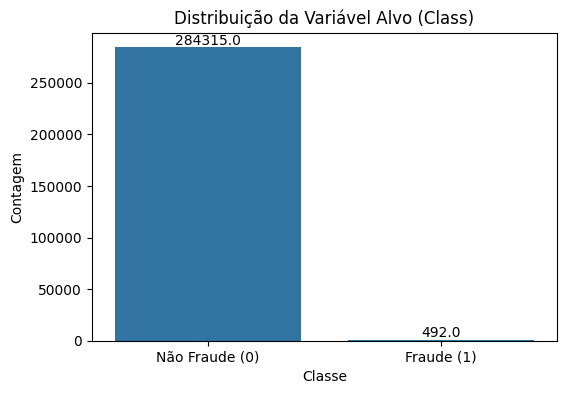

In [5]:
# Verificando o balanceamento da variável alvo 'Class'
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Class', data=base)
plt.title('Distribuição da Variável Alvo (Class)')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.xticks([0, 1], ['Não Fraude (0)', 'Fraude (1)'])

# Adicionar valores em cima das barras
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

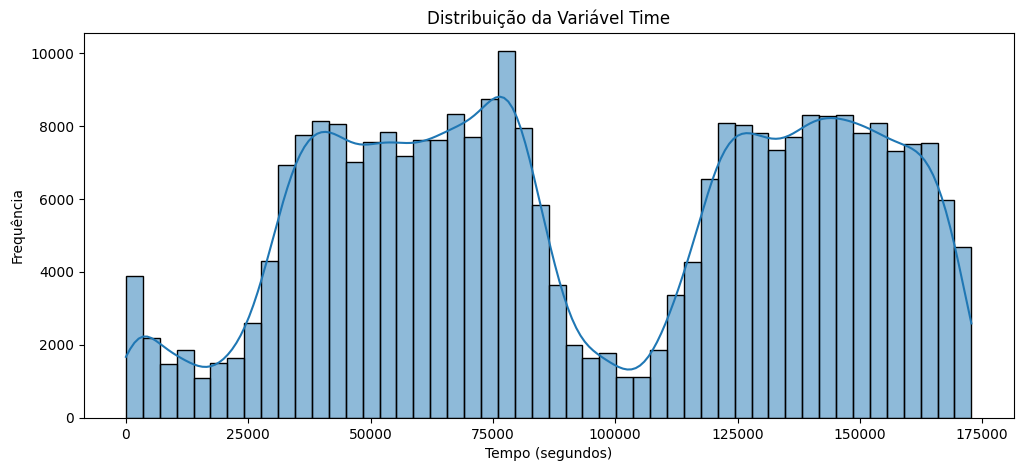

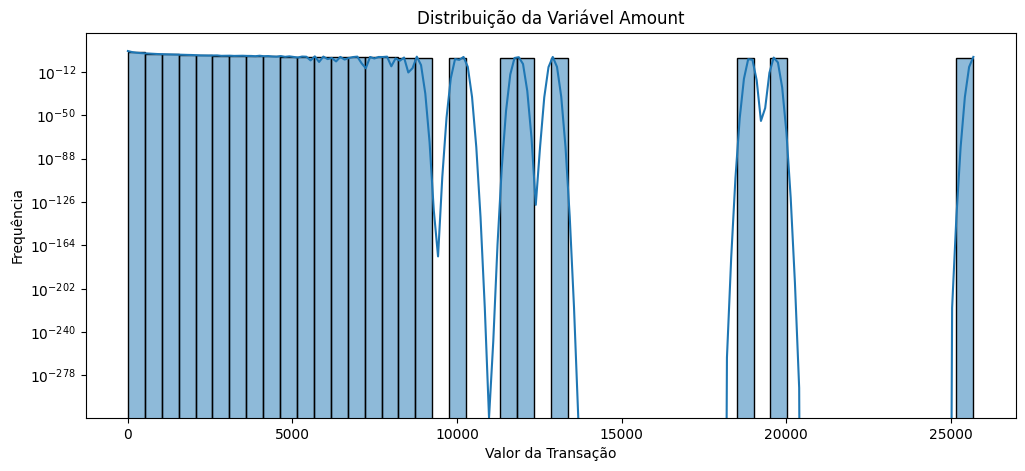

In [10]:
# Análise da distribuição da variável 'Time' com histograma
plt.figure(figsize=(12, 5))
sns.histplot(base['Time'], bins=50, kde=True)
plt.title('Distribuição da Variável Time')
plt.xlabel('Tempo (segundos)')
plt.ylabel('Frequência')
plt.show()

# Análise da distribuição da variável 'Amount' com histograma (escala logarítmica devido à assimetria)
plt.figure(figsize=(12, 5))
sns.histplot(base['Amount'], bins=50, kde=True)
plt.title('Distribuição da Variável Amount')
plt.xlabel('Valor da Transação')
plt.ylabel('Frequência')
plt.yscale('log')
plt.show()

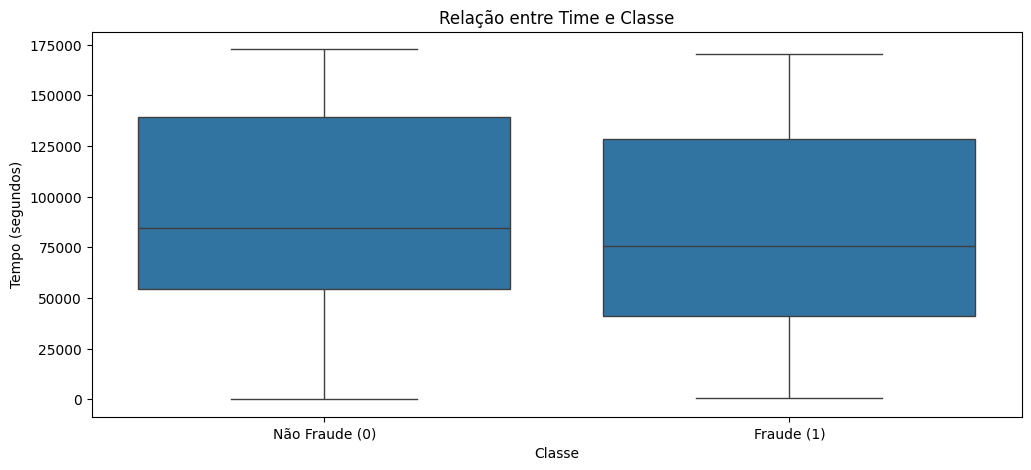

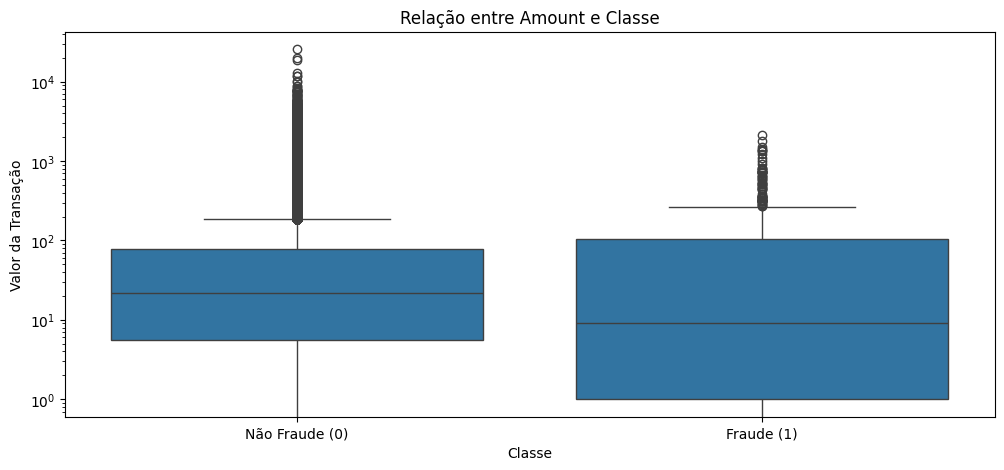

In [11]:
# Relação entre 'Time' e 'Class' usando boxplot
plt.figure(figsize=(12, 5))
sns.boxplot(x='Class', y='Time', data=base)
plt.title('Relação entre Time e Classe')
plt.xlabel('Classe')
plt.ylabel('Tempo (segundos)')
plt.xticks([0, 1], ['Não Fraude (0)', 'Fraude (1)'])
plt.show()

# Relação entre 'Amount' e 'Class' usando boxplot (escala logarítmica)
plt.figure(figsize=(12, 5))
sns.boxplot(x='Class', y='Amount', data=base)
plt.title('Relação entre Amount e Classe')
plt.xlabel('Classe')
plt.ylabel('Valor da Transação')
plt.xticks([0, 1], ['Não Fraude (0)', 'Fraude (1)'])
plt.yscale('log')
plt.show()

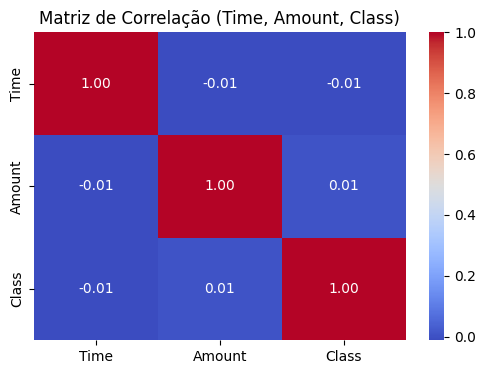

In [12]:
# Selecionando as colunas de interesse para a análise de correlação
selected_columns = ['Time', 'Amount', 'Class']
correlation_subset = base[selected_columns].corr()

# Plotando o heatmap da matriz de correlação para as colunas selecionadas
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_subset, cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Matriz de Correlação (Time, Amount, Class)')
plt.show()

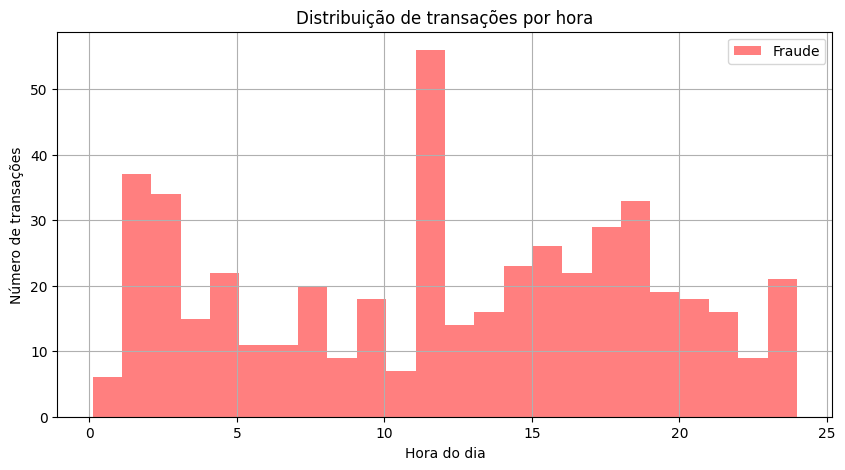

In [13]:
# Converter a variável 'Time' (em segundos) para 'Hour' (em horas do dia)
base['Hour'] = (base['Time'] / 3600) % 24

# Plotar histograma para observar a distribuição de transações fraudulentas ('Class' == 1) por horário
plt.figure(figsize=(10,5))
base[base['Class'] == 1]['Hour'].hist(alpha=0.5, bins=24, label='Fraude', color='red')
plt.legend()
plt.xlabel('Hora do dia')
plt.ylabel('Número de transações')
plt.title('Distribuição de transações por hora')
plt.show()

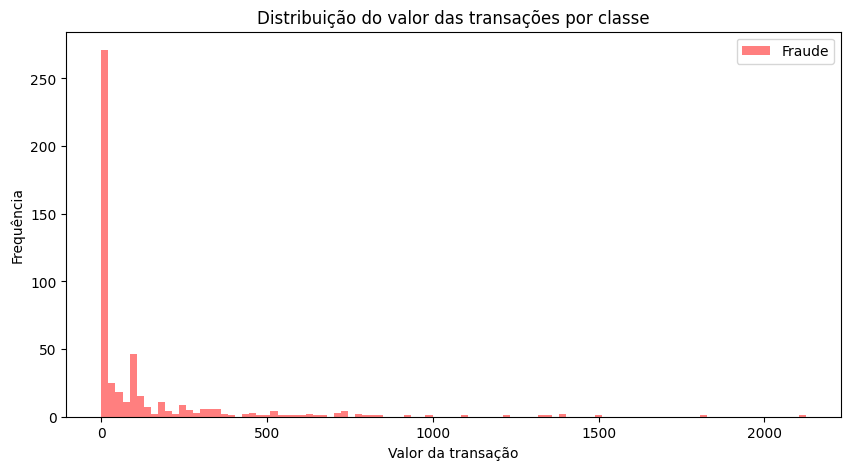

In [14]:
# Plotando histograma do valor das transações para transações fraudulentas
plt.figure(figsize=(10,5))
base[base['Class'] == 1]['Amount'].plot(kind='hist', bins=100, alpha=0.5, label='Fraude', color='red')
plt.legend()
plt.xlabel('Valor da transação')
plt.ylabel('Frequência')
plt.title('Distribuição do valor das transações por classe')
plt.show()

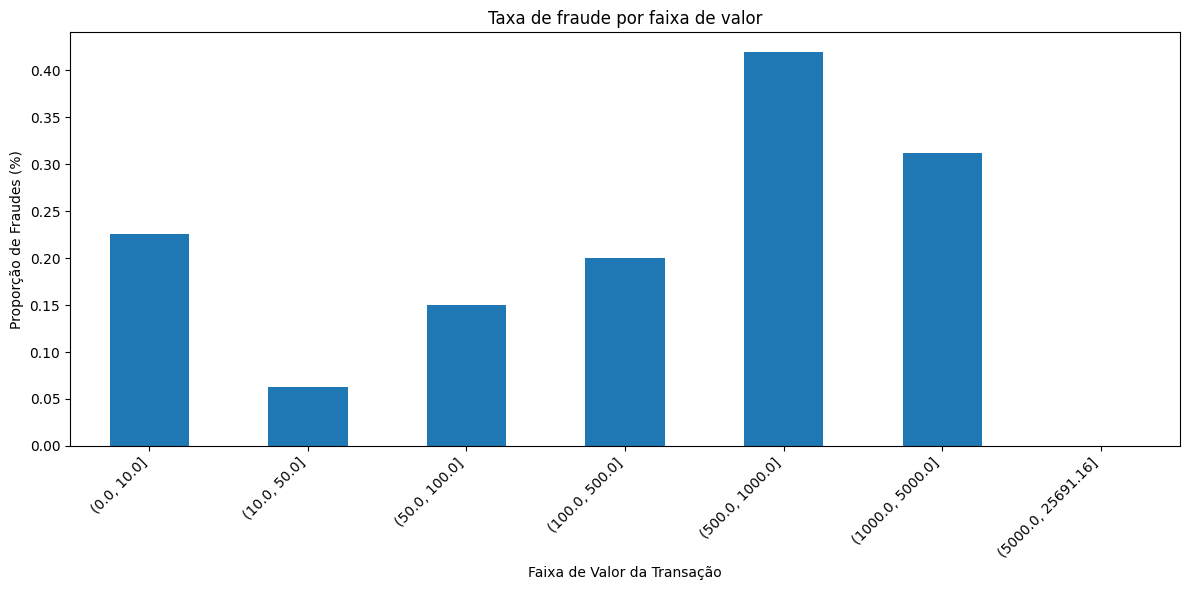

In [15]:
# Criar faixas de valor (bins) para a variável 'Amount'
base['Amount_bin'] = pd.cut(base['Amount'], bins=[0, 10, 50, 100, 500, 1000, 5000, base['Amount'].max()])

# Calcular a taxa de fraude em cada faixa de valor (em porcentagem) agrupando por 'Amount_bin'
taxa_fraude_valor = base.groupby('Amount_bin', observed=False)['Class'].mean() * 100

# Melhorar a visualização do gráfico de barras para a taxa de fraude por faixa de valor
plt.figure(figsize=(12, 6))
taxa_fraude_valor.plot(kind='bar')
plt.title('Taxa de fraude por faixa de valor')
plt.xlabel('Faixa de Valor da Transação')
plt.ylabel('Proporção de Fraudes (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Insights da Análise Exploratória de Dados (EDA)

Com base na Análise Exploratória de Dados (EDA) realizada, mesmo com a maioria das colunas sendo componentes PCA (V1-V28), é possível levantar alguns insights importantes, principalmente focando nas variáveis 'Time', 'Amount' e 'Class':

1.  **Desbalanceamento Extremo:** O insight mais claro e crucial é o **desbalanceamento severo** da variável alvo ('Class'). A vasta maioria das transações não é fraudulenta (Classe 0), enquanto as transações fraudulentas (Classe 1) representam uma porcentagem muito pequena do total.

2.  **Distribuição de 'Time':** A distribuição do tempo das transações mostra picos de atividade em determinados momentos, como das 2-3h da madrugada, mas principalmente ao meio dia.

3.  **Distribuição de 'Amount':** A maioria das transações tem valores baixos, com uma distribuição altamente assimétrica para a direita.

4.  **Correlações:** A matriz de correlação confirmou que as variáveis 'Time' e 'Amount' têm correlações relativamente baixas com a variável 'Class'.

Mesmo com as limitações dos dados pós-PCA, a EDA foi crucial para identificar o problema central do desbalanceamento e entender as características básicas das variáveis 'Time' e 'Amount' em relação à fraude, fornecendo direcionamentos importantes para as próximas etapas de pré-processamento (tratamento do desbalanceamento) e modelagem.

# Pré-processamento e Divisão dos Dados

In [16]:
# Dividindo os dados em features (X) e variável alvo (y), excluindo colunas não utilizadas no modelo
X = base.drop(columns=['Class', 'Hour', 'Amount_bin'])
y = base['Class']

# Dividindo os dados em conjuntos de treino e teste (80% treino, 20% teste)
# Usando stratify=y para garantir que a proporção das classes seja mantida em ambos os conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_train: (227845, 30)
Shape de X_test: (56962, 30)
Shape de y_train: (227845,)
Shape de y_test: (56962,)


In [ ]:
# Escalonamento dos dados para padronizar as features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Shape do X_train original: (227845, 30)
Shape do y_train original: (227845,)
Shape do X_train com SMOTE: (454902, 30)
Shape do y_train com SMOTE: (454902,)


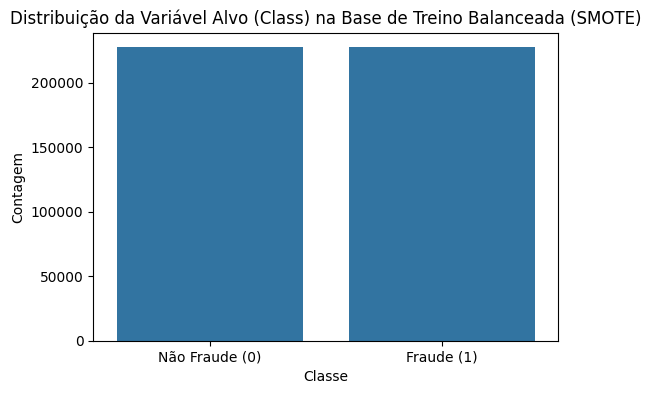

In [17]:
# Tratando o desbalanceamento com SMOTE
# Aplicando SMOTE apenas no conjunto de treino para evitar vazamento de dados para o conjunto de teste
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Shape do X_train original:", X_train.shape)
print("Shape do y_train original:", y_train.shape)
print("Shape do X_train com SMOTE:", X_train_res.shape)
print("Shape do y_train com SMOTE:", y_train_res.shape)

# Verificando o balanceamento após o SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_res)
plt.title('Distribuição da Variável Alvo (Class) na Base de Treino Balanceada (SMOTE)')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.xticks([0, 1], ['Não Fraude (0)', 'Fraude (1)'])
plt.show()

# Iniciando o treinamento dos modelos

In [ ]:
# Dicionário contendo os modelos de machine learning a serem avaliados
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
}

# Avaliação dos modelos com Cross-Validation usando diferentes métricas (F1, Precision, Recall, ROC AUC)
metrics = ['f1', 'precision', 'recall', 'roc_auc']

for nome, modelo in modelos.items():
    print(f"Avaliando {nome}:")
    for metric in metrics:
        scores = cross_val_score(modelo, X_train_res, y_train_res, cv=3, scoring=metric, n_jobs=-1)
        print(f"  {metric.capitalize()} médio = {scores.mean():.4f}")
    print("-" * 30)

Avaliando Regressão Logística:
  F1 médio = 0.9514
  Precision médio = 0.9731
  Recall médio = 0.9305
  Roc_auc médio = 0.9916
------------------------------
Avaliando Random Forest:
  F1 médio = 0.9898
  Precision médio = 0.9982
  Recall médio = 0.9816
  Roc_auc médio = 0.9997
------------------------------
Avaliando Gradient Boosting:
  F1 médio = 0.9651
  Precision médio = 0.9808
  Recall médio = 0.9500
  Roc_auc médio = 0.9965
------------------------------
Avaliando XGBoost:
  F1 médio = 0.9997
  Precision médio = 0.9993
  Recall médio = 1.0000
  Roc_auc médio = 1.0000
------------------------------


Salvando o resultado devido ao alto tempo de processamento (1h 10min).

 Avaliando Regressão Logística:
*  F1 médio = 0.9514
*  Precision médio = 0.9731
*  Recall médio = 0.9305
*  Roc_auc médio = 0.9916


 Avaliando Random Forest:
*  F1 médio = 0.9898
*  Precision médio = 0.9982
*  Recall médio = 0.9816
*  Roc_auc médio = 0.9997

 Avaliando Gradient Boosting:
*  F1 médio = 0.9651
*  Precision médio = 0.9808
*  Recall médio = 0.9500
*  Roc_auc médio = 0.9965

 Avaliando XGBoost:
*  F1 médio = 0.9997
*  Precision médio = 0.9993
*  Recall médio = 1.0000
*  Roc_auc médio = 1.0000


Com base nos resultados médios obtidos através da validação cruzada, onde os modelos Random Forest e XGBoost apresentaram as melhores performances em métricas como F1-score e ROC AUC, focarei na otimização desses dois modelos em busca de melhorar ainda no modelo final.

In [18]:
# 1. Configuração do Caminho para salvar/carregar os resultados da busca
caminho_joblib_rs = '/content/randomized_search_rf.joblib'

# 2. Definição do Modelo e Espaço de Busca para o RandomizedSearchCV
# Definindo o modelo Random Forest com class_weight='balanced' para lidar com o desbalanceamento
# Removendo max_samples do modelo inicial, pois ele será tratado no param_dist_rf
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Definindo o espaço de busca para RandomizedSearchCV (distribuições dos hiperparâmetros a serem amostrados)
param_dist_rf = {
    'n_estimators': randint(50, 200), # Número de árvores na floresta
    'max_depth': randint(3, 15), # Profundidade máxima da árvore
    'min_samples_split': randint(2, 15), # Número mínimo de amostras para dividir um nó interno
    'min_samples_leaf': randint(1, 5), # Número mínimo de amostras em um nó folha
    'max_samples': uniform(0.5, 0.3) # Proporção de amostras a serem retiradas para treinar cada árvore
}


# 3. Bloco TRY-EXCEPT para Carregar ou Executar a Busca de Hiperparâmetros
random_search_rf = None

# Verificando se o arquivo com o resultado da busca existe no diretório
if os.path.exists(caminho_joblib_rs):
    try:
        # Tenta carregar o objeto RandomizedSearchCV completo do arquivo salvo
        random_search_rf = joblib.load(caminho_joblib_rs)
        print("Sucesso: Objeto RandomizedSearchCV carregado do ambiente local (RÁPIDO!)")

    except Exception as e:
        # Em caso de erro ao carregar (arquivo corrompido, etc.), inicia uma nova busca
        print(f"Erro ao carregar o arquivo salvo: {e}. Iniciando nova busca...")
        random_search_rf = None
else:
    print("Arquivo de RandomizedSearchCV não encontrado. Iniciando nova busca (LENTA)...")


if random_search_rf is None:
    # Configurando o RandomizedSearchCV
    random_search_rf = RandomizedSearchCV(
        estimator=rf_model,
        param_distributions=param_dist_rf,
        n_iter=10,
        scoring=['f1', 'recall', 'precision', 'roc_auc'], # Métricas a serem avaliadas durante a validação cruzada
        cv=3,
        verbose=2,
        random_state=42,
        n_jobs=-1,
        refit='f1'
    )

    # Executando a busca
    print("Executando RandomizedSearchCV para Random Forest...")
    random_search_rf.fit(X_train_res, y_train_res) # Treinando no conjunto de treino rebalanceado

    # Salvando o objeto RandomizedSearchCV completo (para uso RÁPIDO DENTRO DESTA SESSÃO ou em futuras)
    print(f"\nBusca concluída. Salvando o resultado em: {caminho_joblib_rs}")
    joblib.dump(random_search_rf, caminho_joblib_rs)

# 4. Avaliação dos Resultados (Funciona Independentemente de ter sido carregado ou treinado)

# Exibindo os melhores parâmetros encontrados pelo RandomizedSearchCV
print("\nMelhores parâmetros encontrados (Random Forest):")
print(random_search_rf.best_params_)
# Exibindo a melhor pontuação (F1) encontrada durante a validação cruzada
print("\nMelhor pontuação (F1) encontrada (Random Forest):")
print(random_search_rf.best_score_)

# Exibindo as pontuações médias das outras métricas para o melhor modelo encontrado
print("\nMétricas para o melhor modelo (Random Forest):")
cv_results = random_search_rf.cv_results_
best_index = random_search_rf.best_index_

# Acessando e exibindo as pontuações médias das métricas
mean_test_f1 = cv_results['mean_test_f1'][best_index]
mean_test_recall = cv_results['mean_test_recall'][best_index]
mean_test_precision = cv_results['mean_test_precision'][best_index]
mean_test_roc_auc = cv_results['mean_test_roc_auc'][best_index]

print(f"  F1 médio = {mean_test_f1:.4f}")
print(f"  Recall médio = {mean_test_recall:.4f}")
print(f"  Precision médio = {mean_test_precision:.4f}")
print(f"  ROC AUC médio = {mean_test_roc_auc:.4f}")

# Salvando o melhor modelo encontrado como uma variável separada para uso posterior
best_rf_model_random = random_search_rf.best_estimator_

Sucesso: Objeto RandomizedSearchCV carregado do ambiente local (RÁPIDO!)

Melhores parâmetros encontrados (Random Forest):
{'max_depth': 13, 'max_samples': np.float64(0.7598528437324805), 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 180}

Melhor pontuação (F1) encontrada (Random Forest):
0.9975495752978222

Métricas para o melhor modelo (Random Forest):
  F1 médio = 0.9975
  Recall médio = 0.9961
  Precision médio = 0.9990
  ROC AUC médio = 1.0000


In [20]:
# 1. Configuração do Caminho para salvar/carregar os resultados da busca
caminho_joblib_xgb_rs = '/content/randomized_search_xgb.joblib'

# 2. Definição do Modelo e Espaço de Busca
# Calcular o balanceamento da classe para o parâmetro scale_pos_weight
scale_pos_weight_value = len(y_train_res[y_train_res == 0]) / len(y_train_res[y_train_res == 1])

# Modelo base do XGBoost
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight_value, # Parâmetro para lidar com o desbalanceamento de classes
    tree_method='hist', # Método para construir as árvores (mais rápido para grandes datasets)
    n_jobs=-1,
    verbosity=0
)

# Espaço de busca otimizado (leve, mas com boa cobertura) para RandomizedSearchCV
param_dist_xgb = {
    'n_estimators': randint(80, 200),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'gamma': uniform(0, 0.4)
}

# 3. Bloco TRY-EXCEPT para Carregar ou Executar a Busca
# Verificando se o arquivo existe no diretório para carregar os resultados salvos
random_search_xgb = None

if os.path.exists(caminho_joblib_xgb_rs):
    try:
        # Tenta carregar o objeto RandomizedSearchCV completo do arquivo salvo
        random_search_xgb = joblib.load(caminho_joblib_xgb_rs)
        print(" Sucesso: Objeto RandomizedSearchCV para XGBoost carregado do ambiente local (RÁPIDO!)")
    except Exception as e:
        # Em caso de erro ao carregar (arquivo corrompido, etc.), inicia uma nova busca
        print(f" Erro ao carregar o arquivo salvo: {e}. Iniciando nova busca para XGBoost...")
        random_search_xgb = None
else:
    print(" Arquivo de RandomizedSearchCV para XGBoost não encontrado. Iniciando nova busca (LENTA)...")

# 4. Execução do RandomizedSearchCV (se o objeto não foi carregado)
if random_search_xgb is None:
    # Definindo as métricas de scoring para avaliação durante a busca
    scoring = {
        'f1': make_scorer(f1_score),
        'recall': make_scorer(recall_score),
        'precision': make_scorer(precision_score),
        'roc_auc': 'roc_auc',
        'accuracy': 'accuracy'
    }

    # Configurando o RandomizedSearchCV
    random_search_xgb = RandomizedSearchCV(
        estimator=xgb_model,
        param_distributions=param_dist_xgb,
        n_iter=20,
        scoring=scoring,
        refit='f1',
        cv=5,
        n_jobs=-1,
        random_state=42
    )

    print(" Executando RandomizedSearchCV para XGBoost...")
    # Executando a busca no conjunto de treino rebalanceado
    random_search_xgb.fit(X_train_res, y_train_res)

    print(f"\n Busca concluída. Salvando o resultado em: {caminho_joblib_xgb_rs}")
    # Salvando o objeto RandomizedSearchCV completo
    joblib.dump(random_search_xgb, caminho_joblib_xgb_rs)

# 5. Avaliação dos Resultados (Funciona Independentemente de ter sido carregado ou treinado)

# Exibindo os melhores parâmetros encontrados
print("\n Melhores parâmetros encontrados (XGBoost):")
print(random_search_xgb.best_params_)

# Exibindo a melhor pontuação (F1) encontrada durante a validação cruzada
print("\n Melhor pontuação (F1) encontrada (XGBoost):")
print(random_search_xgb.best_score_)

# Acessando os resultados detalhados da validação cruzada
cv_results_xgb = random_search_xgb.cv_results_
best_index_xgb = random_search_xgb.best_index_

# Exibindo as pontuações médias das métricas para o melhor modelo encontrado
mean_test_f1_xgb = cv_results_xgb['mean_test_f1'][best_index_xgb]
mean_test_recall_xgb = cv_results_xgb['mean_test_recall'][best_index_xgb]
mean_test_precision_xgb = cv_results_xgb['mean_test_precision'][best_index_xgb]
mean_test_roc_auc_xgb = cv_results_xgb['mean_test_roc_auc'][best_index_xgb]
mean_test_accuracy_xgb = cv_results_xgb['mean_test_accuracy'][best_index_xgb]

print("\n Métricas para o melhor modelo (XGBoost):")
print(f"  F1 médio = {mean_test_f1_xgb:.4f}")
print(f"  Recall médio = {mean_test_recall_xgb:.4f}")
print(f"  Precision médio = {mean_test_precision_xgb:.4f}")
print(f"  ROC AUC médio = {mean_test_roc_auc_xgb:.4f}")
print(f"  Accuracy médio = {mean_test_accuracy_xgb:.4f}")

# Salvando o melhor modelo encontrado como uma variável separada para uso posterior
best_xgb_model_random = random_search_xgb.best_estimator_

 Sucesso: Objeto RandomizedSearchCV para XGBoost carregado do ambiente local (RÁPIDO!)

 Melhores parâmetros encontrados (XGBoost):
{'colsample_bytree': np.float64(0.7467983561008608), 'gamma': np.float64(0.023233444867279785), 'learning_rate': np.float64(0.18323522915498705), 'max_depth': 6, 'n_estimators': 183, 'subsample': np.float64(0.9124217733388136)}

 Melhor pontuação (F1) encontrada (XGBoost):
0.9997582518522743

 Métricas para o melhor modelo (XGBoost):
  F1 médio = 0.9998
  Recall médio = 1.0000
  Precision médio = 0.9995
  ROC AUC médio = 1.0000
  Accuracy médio = 0.9998


Como os resultados do Randomized Search para o Random Forest e XGBoost foram satisfatórios (próximos a 100%), optarei por não realizar o treinamento com Grid Search neste momento. Esta decisão visa otimizar o tempo de processamento e evitar o overfitting, dado o bom desempenho já alcançado por ambos os modelos.

Avaliando o melhor modelo Random Forest (Randomized Search) no conjunto de teste:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.79      0.75        98

    accuracy                           1.00     56962
   macro avg       0.86      0.89      0.88     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.9752755949031272


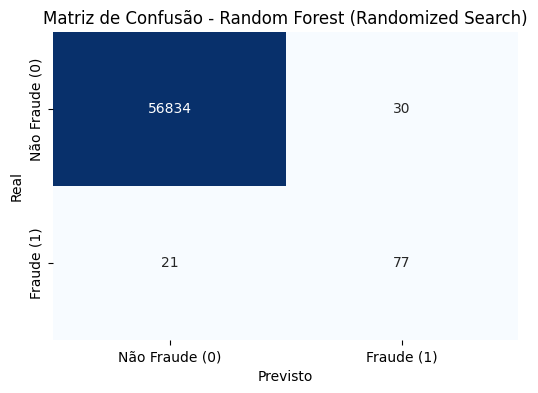

------------------------------
Avaliando o melhor modelo XGBoost (Randomized Search) no conjunto de teste:
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.82      0.78        98

    accuracy                           1.00     56962
   macro avg       0.87      0.91      0.89     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.9832663756273472


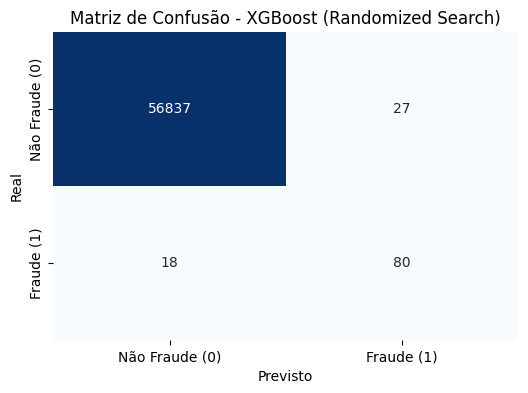

------------------------------


In [21]:
# Avaliação dos melhores modelos no conjunto de teste

print("Avaliando o melhor modelo Random Forest (Randomized Search) no conjunto de teste:")
y_pred_rf_random = best_rf_model_random.predict(X_test)
y_proba_rf_random = best_rf_model_random.predict_proba(X_test)[:, 1] # Obter probabilidades para ROC AUC

print("Classification Report:")
print(classification_report(y_test, y_pred_rf_random))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_rf_random))

# Gerando e exibindo a Matriz de Confusão para visualizar o desempenho do modelo
cm_rf_random = confusion_matrix(y_test, y_pred_rf_random)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf_random, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não Fraude (0)', 'Fraude (1)'],
            yticklabels=['Não Fraude (0)', 'Fraude (1)'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Random Forest (Randomized Search)')
plt.show()

print("-" * 30)


# Avaliação do melhor modelo XGBoost (Randomized Search) no conjunto de teste:
print("Avaliando o melhor modelo XGBoost (Randomized Search) no conjunto de teste:")
y_pred_xgb_random = best_xgb_model_random.predict(X_test)
y_proba_xgb_random = best_xgb_model_random.predict_proba(X_test)[:, 1] # Obter probabilidades para ROC AUC

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb_random))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_xgb_random))

# Gerando e exibindo a Matriz de Confusão para visualizar o desempenho do modelo
cm_xgb_random = confusion_matrix(y_test, y_pred_xgb_random)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb_random, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não Fraude (0)', 'Fraude (1)'],
            yticklabels=['Não Fraude (0)', 'Fraude (1)'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - XGBoost (Randomized Search)')
plt.show()

print("-" * 30)

## Ajuste do Limite de Decisão (Threshold)

Considerando os objetivos do projeto e a natureza desbalanceada dos dados, decidi ajustar o limite de decisão (threshold) do modelo para otimizar o trade-off entre a identificação de fraudes (Recall) e a minimização de falsos positivos (Precision).

Melhor threshold (baseado no F1-Score): 0.9808
F1-Score máximo neste threshold: 0.8652

Classification Report com o Melhor Threshold:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.79      0.87        98

    accuracy                           1.00     56962
   macro avg       0.98      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



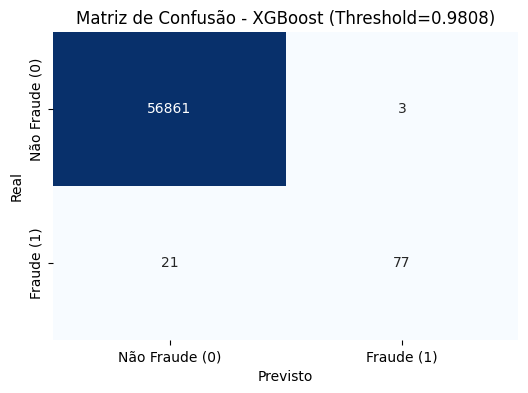

In [ ]:
# 1. Obter as probabilidades do modelo (em vez das classes)
# Usando o melhor modelo XGBoost do Randomized Search
y_proba = best_xgb_model_random.predict_proba(X_test)[:, 1]  # probabilidade da classe 1

# 2. Calcular a curva Precision-Recall
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# 3. Avaliar vários thresholds para encontrar o melhor F1-Score
# Evitar a divisão por zero onde Precision + Recall = 0
f1_scores = np.where((precisions + recalls) == 0, 0, 2 * (precisions * recalls) / (precisions + recalls))


# 4. Escolher o threshold com melhor F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Melhor threshold (baseado no F1-Score): {best_threshold:.4f}")
print(f"F1-Score máximo neste threshold: {f1_scores[best_idx]:.4f}")

# Opcional: Avaliar o modelo no conjunto de teste usando o novo threshold
y_pred_threshold = (y_proba >= best_threshold).astype(int)

print("\nClassification Report com o Melhor Threshold:")
print(classification_report(y_test, y_pred_threshold))

# Gerando e exibindo a Matriz de Confusão com o novo threshold
cm_threshold = confusion_matrix(y_test, y_pred_threshold)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_threshold, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não Fraude (0)', 'Fraude (1)'],
            yticklabels=['Não Fraude (0)', 'Fraude (1)'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title(f'Matriz de Confusão - XGBoost (Threshold={best_threshold:.4f})')
plt.show()

O ajuste do threshold teve um impacto significativo no desempenho do modelo:

**Otimização do F1-Score:** O F1-score para a classe minoritária (Fraude) aumentou de 0.78 para 0.87. Isso indica que o novo threshold encontrou um melhor equilíbrio entre Precision e Recall para identificar fraudes.

*Impacto nos Falsos Negativos:* Nesse ajuste, o número de Falsos Negativos aumentou de 17 para 21 apesar de otimizar o F1-Score. Isso significa que mais transações fraudulentas foram classificadas incorretamente como não fraudulentas após o ajuste.

*Impacto nos Falsos Positivos:* Mas ao mesmo tempo, os faltos positivos saíram de 27 para 3. Isso significa que menos transações legítimas foram classificadas incorretamente como fraudulentas após o ajuste.

# Conclusão Final

Com base na análise e modelagem realizadas neste notebook, o objetivo de desenvolver e otimizar um modelo de detecção de fraudes foi abordado através das seguintes etapas:

1.  **Análise Exploratória de Dados (EDA):** Identificação do severo desbalanceamento da variável alvo e características básicas das variáveis 'Time' e 'Amount'.
2.  **Pré-processamento:** Tratamento do desbalanceamento com SMOTE e escalonamento das features.
3.  **Modelagem e Otimização:** Treinamento e ajuste de hiperparâmetros para modelos como Random Forest e XGBoost utilizando Randomized Search.
4.  **Avaliação:** Análise de desempenho no conjunto de teste real (desbalanceado) utilizando métricas como F1-Score, Precision, Recall e ROC AUC, além da Matriz de Confusão. Exploração do ajuste de limite de decisão (threshold) para otimizar o trade-off entre Recall e Precision.



### **Principais Resultados e Escolha do Modelo:**

*   Na avaliação no conjunto de teste com o threshold padrão, o modelo **XGBoost (Randomized Search)** apresentou um desempenho superior ao **Random Forest (Randomized Search)**, com um F1-Score de 0.78 vs 0.75, Precision de 0.75 vs 0.72, Recall de 0.82 vs 0.79 e ROC AUC de 0.9832 vs 0.9752 para a classe Fraude. O XGBoost também teve ligeiramente menos Falsos Positivos (30 vs 27) e um pouco menos de Falsos Negativos (18 vs 21) em comparação com o Random Forest.

*   Ajustando o threshold do XGBoost para otimizar o F1-Score (threshold de 0.9808), conseguimos um F1-Score de 0.87, com Precision de 0.96 e Recall de 0.79. A Matriz de Confusão resultante mostrou 3 Falsos Positivos e 21 Falsos Negativos.

*   Considerando o melhor equilíbrio entre Precision e Recall, refletido no F1-Score mais alto, e a capacidade de ajuste via threshold para gerenciar Falsos Positivos e Falsos Negativos, o modelo **XGBoost com o threshold otimizado para F1 (0.9808)** foi a abordagem mais promissora para este problema, oferecendo alta precisão nas detecções de fraude e um Recall razoável.


### **Considerações Finais:**

O desbalanceamento extremo do dataset foi o principal desafio, e o uso de SMOTE no treino foi crucial para permitir que os modelos aprendessem a identificar a classe minoritária. A escolha do threshold demonstrou ser fundamental para adaptar o modelo aos objetivos de negócio específicos (priorizando F1-Score).

Este projeto demonstra o processo de ponta a ponta para construir e avaliar modelos de detecção de fraude em um conjunto de dados desbalanceado, culminando na identificação de um modelo e threshold mais adequados para este problema.